In [139]:
# import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import xmltodict
from scipy.stats import hmean
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# 1. Request Data from API

In [16]:

# 1. Define the API endpoint for "Advanced Vehicles" (EVs, Hybrids, etc.)
# We loop through recent years to get a modern dataset
years = range(2020, 2025) 
data_list = []

print("Fetching EV & Hybrid data... (This scrapes multiple pages)")

for year in years:
    url = f"https://www.fueleconomy.gov/ws/rest/vehicle/menu/options?year={year}&make=Tesla" 
    # Note: For a portfolio, we can iterate through ALL makes, but to keep this script 
    # simple and fast for you to test, we'll fetch Tesla, Ford, and BMW first.
    # In a real project, you'd loop through all makes.
    
    makes = ['Tesla', 'Ford', 'BMW', 'Nissan', 'Chevy', 'Rivian', 'Lucid', 'Hyundai', 'Kia']
    
    for make in makes:
        # Get list of models for this Make + Year
        model_url = f"https://www.fueleconomy.gov/ws/rest/vehicle/menu/model?year={year}&make={make}"
        try:
            r = requests.get(model_url)
            models = xmltodict.parse(r.content)['menuItems']['menuItem']
            
            # Handle case where only 1 model exists (dict) vs multiple (list)
            if isinstance(models, dict): models = [models]
            
            for model_item in models:
                model_name = model_item['value']
                
                # Get specific vehicle ID to fetch details
                # We need the "options" endpoint to get the ID
                opt_url = f"https://www.fueleconomy.gov/ws/rest/vehicle/menu/options?year={year}&make={make}&model={model_name}"
                r_opt = requests.get(opt_url)
                options = xmltodict.parse(r_opt.content)['menuItems']['menuItem']
                if isinstance(options, dict): options = [options]
                
                vehicle_id = options[0]['value'] # Just grab the first trim for simplicity
                
                # FINAL CALL: Get the actual specs using vehicle ID
                # This is the rich data endpoint
                detail_url = f"https://www.fueleconomy.gov/ws/rest/vehicle/{vehicle_id}"
                r_detail = requests.get(detail_url)
                car = xmltodict.parse(r_detail.content)['vehicle']
                
                # Filter for Electric/Hybrid only
                if car['fuelType'] in ['Electricity', 'Regular Gas and Electricity', 'Premium Gas and Electricity']:
                    data_list.append({
                        'make': car['make'],
                        'model': car['model'],
                        'year': car['year'],
                        'fuel_type': car['fuelType'], # BEV vs Hybrid
                        'range': float(car['range']) if car['range'] else 0, # Total Range
                        'city_mpge': float(car['city08']), # City efficiency
                        'hwy_mpge': float(car['highway08']), # Highway efficiency
                        'co2_emissions': float(car['co2']) if car['co2'] else 0, # Tailpipe emissions
                        'charge_time_240v': float(car['charge240']) if car['charge240'] else 0
                    })
        except Exception as e:
            continue

# 2. Save to CSV
df = pd.DataFrame(data_list)
df.to_csv('green_vehicles.csv', index=False)
print(f"Success! Saved {len(df)} green vehicles to green_vehicles.csv")

Fetching EV & Hybrid data... (This scrapes multiple pages)


KeyboardInterrupt: 

# 2. Data Cleaning and Manipulating

In [120]:
# Read and display the saved data
green_df = pd.read_csv('green_vehicles.csv')
green_df.head()

,make,model,year,fuel_type,range,city_mpge,hwy_mpge,co2_emissions,charge_time_240v
0,Tesla,Model 3 Long Range,2020,Electricity,330.0,136.0,123.0,0.0,10.0
1,Tesla,Model 3 Long Range AWD,2020,Electricity,322.0,124.0,116.0,0.0,10.0
2,Tesla,Model 3 Long Range Performance AWD (18in),2020,Electricity,322.0,124.0,116.0,0.0,10.0
3,Tesla,Model 3 Long Range Performance AWD (19in),2020,Electricity,304.0,119.0,112.0,0.0,10.0
4,Tesla,Model 3 Long Range Performance AWD (20in),2020,Electricity,299.0,118.0,107.0,0.0,10.0


In [121]:
# Display basic info about the dataset
green_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   make              349 non-null    object 
 1   model             349 non-null    object 
 2   year              349 non-null    int64  
 3   fuel_type         349 non-null    object 
 4   range             349 non-null    float64
 5   city_mpge         349 non-null    float64
 6   hwy_mpge          349 non-null    float64
 7   co2_emissions     349 non-null    float64
 8   charge_time_240v  349 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 24.7+ KB


In [122]:
# Display basic statistics about the dataset
green_df.describe()

,year,range,city_mpge,hwy_mpge,co2_emissions,charge_time_240v
count,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000
mean,2022.747851,316.762178,99.088825,89.277937,6.223496,10.331375
std,1.334566,85.207409,26.585702,23.222935,23.261542,3.107318
min,2020.000000,149.000000,33.000000,32.000000,0.000000,1.700000
25%,2022.000000,269.000000,80.000000,74.000000,0.000000,8.400000
50%,2023.000000,305.000000,100.000000,92.000000,0.000000,10.400000
75%,2024.000000,348.000000,121.000000,106.000000,0.000000,13.000000
max,2024.000000,630.000000,153.000000,140.000000,111.000000,15.300000


In [123]:
# Check for duplicates and missing values
print("Number of duplicates:", green_df.duplicated().sum()) # Check for duplicates
print("Missing values per column:")
print(green_df.isnull().sum()) # Check for missing values

Number of duplicates: 0
Missing values per column:
make                0
model               0
year                0
fuel_type           0
range               0
city_mpge           0
hwy_mpge            0
co2_emissions       0
charge_time_240v    0
dtype: int64


In [124]:
# Calculate miles per kWh for city and highway
green_df['city_miles_per_kwh'] = green_df['city_mpge'] / 33.7
green_df['hwy_miles_per_kwh'] = green_df['hwy_mpge'] / 33.7

# Feature Engineering: Calculate total energy consumption (kWh) for the range
green_df['combined_miles_per_kwh'] = (green_df['city_miles_per_kwh'] * 0.55) + (green_df['hwy_miles_per_kwh'] * 0.45)
green_df['total_energy(battery_size)'] = green_df['range'] / green_df['combined_miles_per_kwh']

# Interaction Term: total_energy * efficiency
green_df['Interaction_Term'] = green_df['total_energy(battery_size)'] * green_df['combined_miles_per_kwh']          
               
green_df.head()

,make,model,year,fuel_type,range,city_mpge,hwy_mpge,co2_emissions,charge_time_240v,city_miles_per_kwh,hwy_miles_per_kwh,combined_miles_per_kwh,total_energy(battery_size),Interaction_Term
0,Tesla,Model 3 Long Range,2020,Electricity,330.0,136.0,123.0,0.0,10.0,4.035608,3.649852,3.862018,85.447561,330.0
1,Tesla,Model 3 Long Range AWD,2020,Electricity,322.0,124.0,116.0,0.0,10.0,3.679525,3.442136,3.572700,90.127907,322.0
2,Tesla,Model 3 Long Range Performance AWD (18in),2020,Electricity,322.0,124.0,116.0,0.0,10.0,3.679525,3.442136,3.572700,90.127907,322.0
3,Tesla,Model 3 Long Range Performance AWD (19in),2020,Electricity,304.0,119.0,112.0,0.0,10.0,3.531157,3.323442,3.437685,88.431593,304.0
4,Tesla,Model 3 Long Range Performance AWD (20in),2020,Electricity,299.0,118.0,107.0,0.0,10.0,3.501484,3.175074,3.354599,89.131358,299.0


In [125]:
# Convert 'fuel_type' to simpler categories
def simplify_fuel(f):
    if 'Electricity' == f: return 'BEV' # Battery Electric
    else: return 'PHEV' # Plug-in Hybrid
    
green_df['type'] = green_df['fuel_type'].apply(simplify_fuel)

# Filter: Let's focus strictly on BEVs (Pure Electric) for the Regression analysis
# because comparing Hybrid range (gas) vs Electric range is apples-to-oranges.
df_bev = green_df[green_df['type'] == 'BEV'].copy()

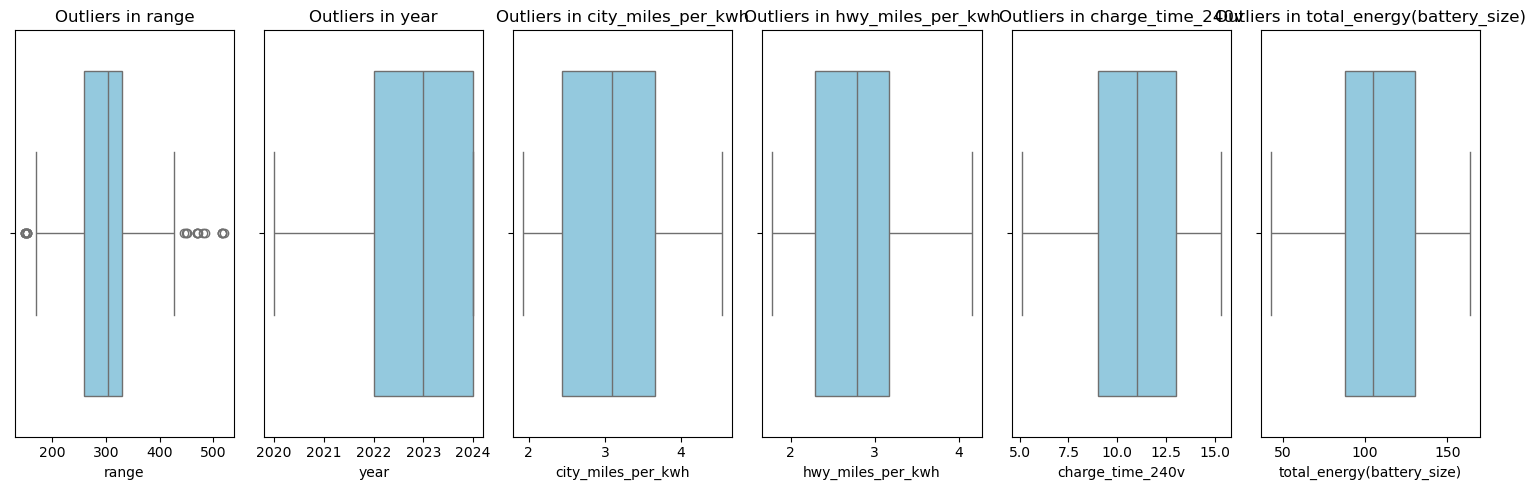

In [ ]:
# Visualize Outliers with Box Plots
#  create a list of columns to check
cols_to_check = ['range', 'year', 'city_miles_per_kwh', 'hwy_miles_per_kwh', 'charge_time_240v', 'total_energy(battery_size)']

plt.figure(figsize=(15, 5))

# Plot box plots for each column

for i, col in enumerate(cols_to_check):
    plt.subplot(1, 6, i+1)
    sns.boxplot(x=df_bev[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

##### The charts show that most categories like battery size and charging time are very consistent with no unexpected spikes. However, the Range chart has a few separate dots on the far right which represent exceptional cars that drive much further than everything else. This proves that while most electric vehicles share similar specs, a small group of outliers is performing far above the industry standard.

##### We should not remove these outliers because they are real, record-breaking cars like the Lucid Air rather than mistakes in the data. If we delete them, we would accidentally hide the industry leaders and make our analysis of the best vehicles completely wrong. These special points represent the winning technology that we actually want to study.

# 3. Explatory Data Analysis (EDA)

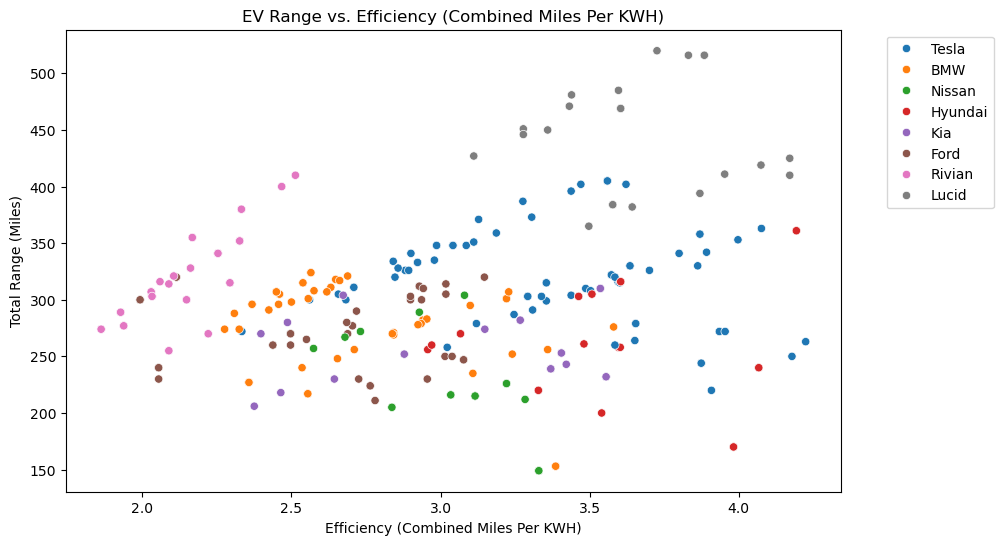

In [127]:
# Scatter plot: Range vs. Combined Miles per kWh
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_bev, x='combined_miles_per_kwh', y='range', hue='make')
plt.title("EV Range vs. Efficiency (Combined Miles Per KWH)")
plt.xlabel("Efficiency (Combined Miles Per KWH)")
plt.ylabel("Total Range (Miles)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### The chart reveals that being efficient is not the only way to achieve a long driving range. Heavy vehicles like Rivian have low efficiency but still drive far because they rely on massive batteries to compensate for their weight. In contrast, highly efficient cars like Tesla and Hyundai achieve similar or better distances while using much smaller and lighter batteries.

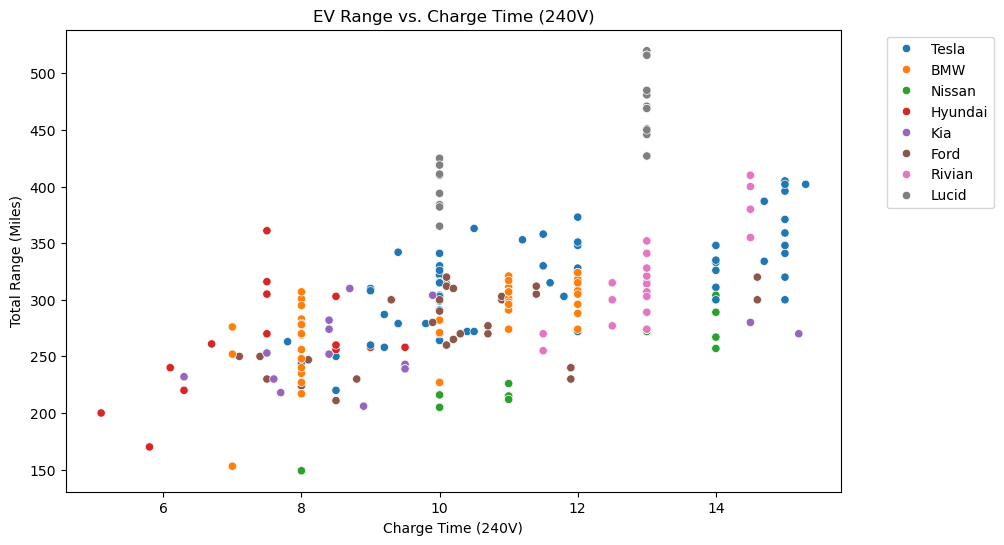

In [128]:
# Scatter plot: Range vs. Charge Time (240V)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_bev, x='charge_time_240v', y='range', hue='make')
plt.title("EV Range vs. Charge Time (240V)")
plt.xlabel("Charge Time (240V)")
plt.ylabel("Total Range (Miles)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### The data shows that cars taking longer to charge generally drive further because they have larger batteries that take more time to fill up. However, heavy trucks like Rivian take the longest to charge but do not achieve the highest range, proving they use more energy to move. In contrast, Lucid models drive the furthest distance without needing the absolute longest charging time, showing they use their power much more effectively.

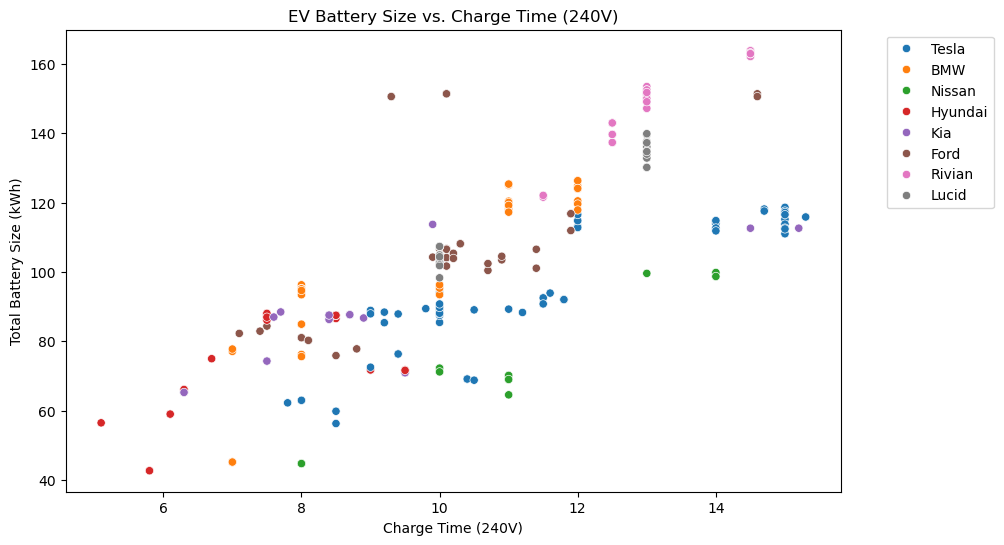

In [129]:
# Scatter plot: Battery Size vs. Charge Time (240V)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_bev, x='charge_time_240v', y='total_energy(battery_size)', hue='make')
plt.title("EV Battery Size vs. Charge Time (240V)")
plt.xlabel("Charge Time (240V)")
plt.ylabel("Total Battery Size (kWh)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### The chart confirms a clear rule: the bigger the battery, the longer it takes to charge. You can see that large trucks like Rivian (in pink) are at the top right because they have massive batteries that require the most time to fill up. In contrast, smaller cars are at the bottom left, showing that a fast charging time often just means you have a smaller "tank" to refill.

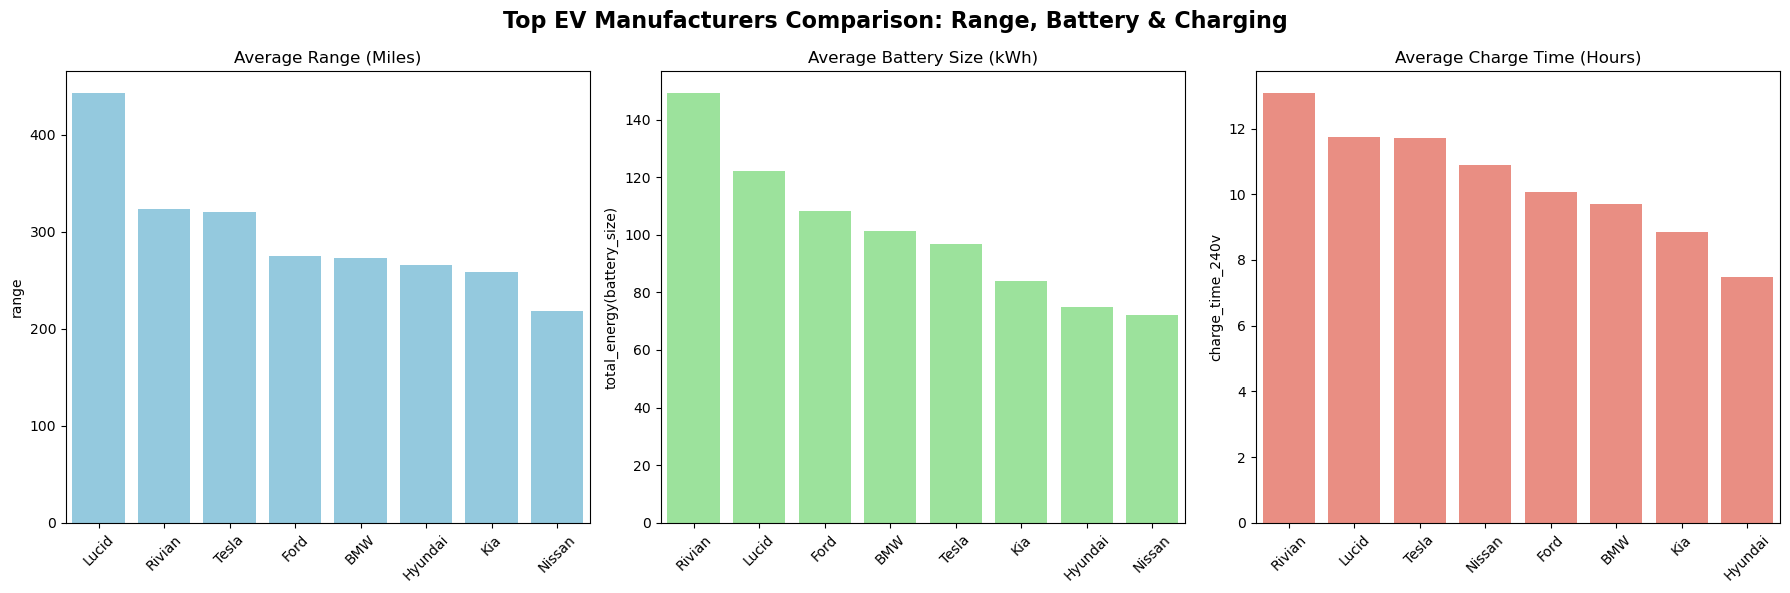

In [142]:
# Bar plots: Top Manufacturers by Avg Range, Battery Size, Charge Time
topman = df_bev.groupby('make')[['range', 'total_energy(battery_size)', 'charge_time_240v']].mean().sort_values(by='range', ascending=False).reset_index()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Range
sns.barplot(data=topman, x='make', y='range', color='skyblue', ax=ax1)
ax1.set_title('Average Range (Miles)')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel('')

# Plot 2: Battery Size
sns.barplot(data=topman, x='make', y='total_energy(battery_size)', color='lightgreen', ax=ax2, order=topman.sort_values('total_energy(battery_size)', ascending=False)['make'])
ax2.set_title('Average Battery Size (kWh)')
ax2.tick_params(axis='x', rotation=45)
ax2.set_xlabel('')

# Plot 3: Charge Time
sns.barplot(data=topman, x='make', y='charge_time_240v', color='salmon', ax=ax3, order=topman.sort_values('charge_time_240v',ascending=False)['make'])
ax3.set_title('Average Charge Time (Hours)')
ax3.tick_params(axis='x', rotation=45)
ax3.set_xlabel('')

# Add the Main Title
fig.suptitle('Top EV Manufacturers Comparison: Range, Battery & Charging', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

##### Lucid is the clear winner for long-distance driving, beating all other brands by a wide margin. Rivian has the biggest battery but also the longest wait time to charge, proving that simply adding a huge battery isn't the most efficient solution. On the other hand, Hyundai stands out for having the fastest charging speed, making it a great choice for drivers who want quick stops.

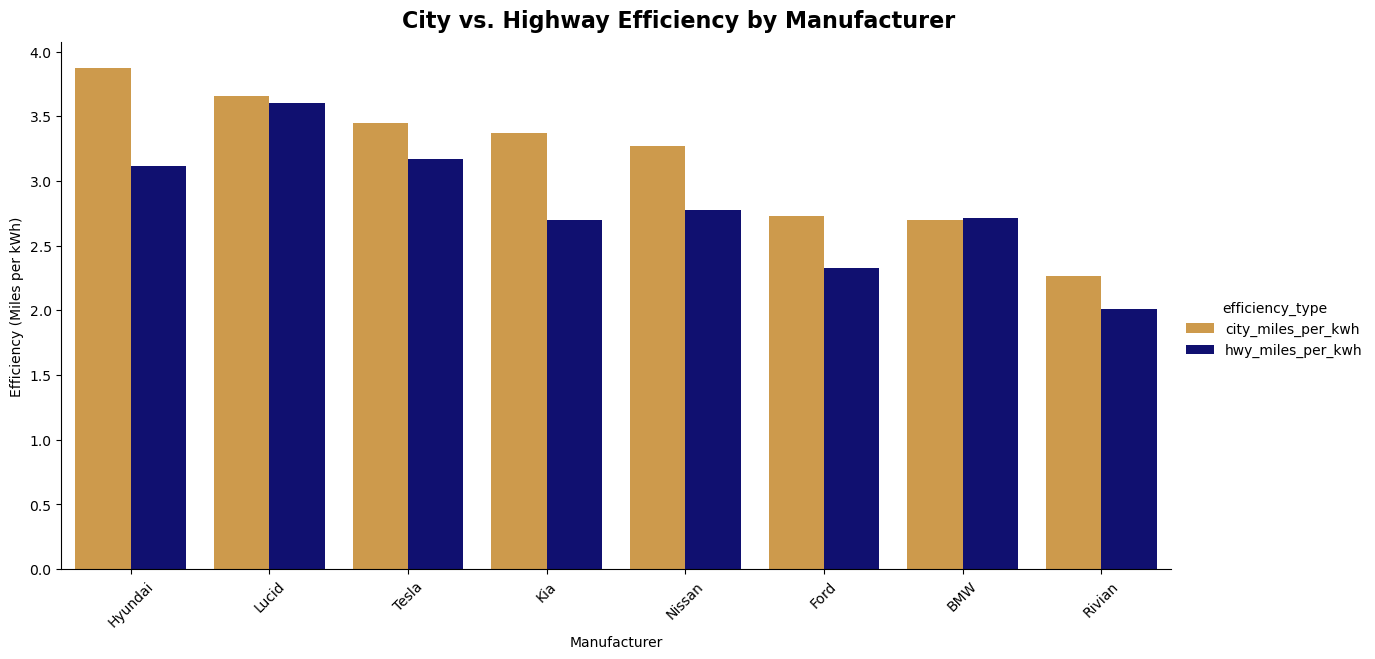

In [143]:
# harmonic mean for miles per kWh
mileskwh = df_bev.groupby('make')[['city_miles_per_kwh', 'hwy_miles_per_kwh']].agg(hmean).sort_values(by='city_miles_per_kwh', ascending=False).reset_index()

# melt data for seaborn
df_bevmelted = mileskwh.melt(id_vars='make', value_vars=['city_miles_per_kwh', 'hwy_miles_per_kwh'], var_name='efficiency_type', value_name='miles_per_kwh')

# plot miles per kWh
graph = sns.catplot(data=df_bevmelted, kind='bar', x='make', y='miles_per_kwh', hue='efficiency_type', palette={'city_miles_per_kwh': '#E29E37', 'hwy_miles_per_kwh': '#000080'}, height=6, aspect=2)

graph.set_axis_labels("Manufacturer", "Efficiency (Miles per kWh)")

# Add the Main Title
graph.fig.suptitle('City vs. Highway Efficiency by Manufacturer', fontsize=16, weight='bold', y=1.03)

# Rotate x-axis labels for better readability
graph.set_xticklabels(rotation=45)

plt.show()

##### This chart proves that Hyundai, Lucid, and Tesla are the most efficient brands, meaning they travel the furthest using the least amount of electricity. It also reveals that almost every electric car performs better in city driving than on the highway, as the brown bars are consistently higher than the blue ones. In contrast, Rivian is the least efficient manufacturer, likely because its heavy vehicles require much more power to move.

In [132]:
# Top Models by Avg Range, Battery Size, Charge Time
topmodel_range = df_bev.groupby('model')['range'].mean().sort_values(ascending=False).reset_index().head(10)
topmodel_totalenergy = df_bev.groupby('model')['total_energy(battery_size)'].mean().sort_values(ascending=False).reset_index().head(10)
topmodel_charge = df_bev.groupby('model')['charge_time_240v'].mean().sort_values(ascending=False).reset_index().head(10)


/var/folders/m6/kchw2h3943z39q2k6bmlw1f80000gn/T/ipykernel_1226/1359364835.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/m6/kchw2h3943z39q2k6bmlw1f80000gn/T/ipykernel_1226/1359364835.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/m6/kchw2h3943z39q2k6bmlw1f80000gn/T/ipykernel_1226/1359364835.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


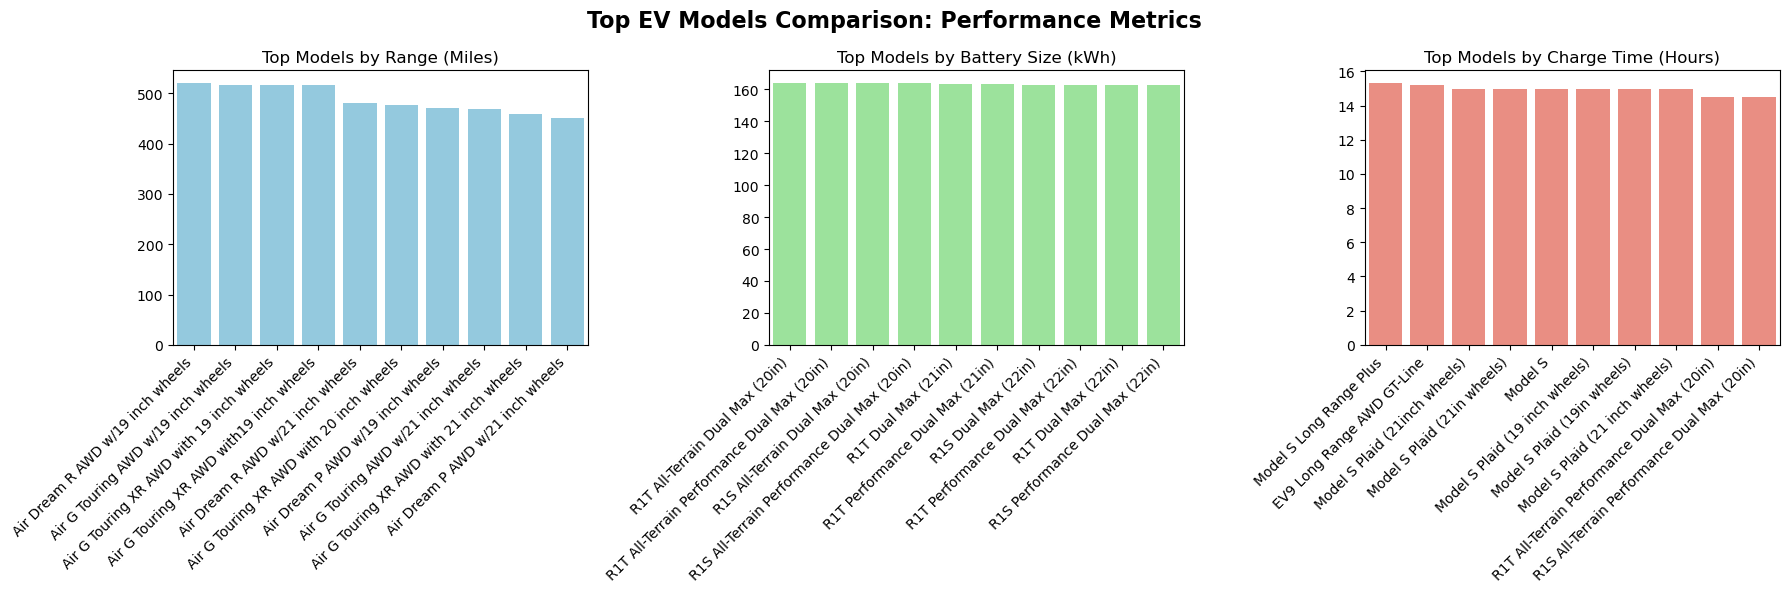

In [144]:
# Create the figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Range
sns.barplot(data=topmodel_range, x='model', y='range', color='skyblue', ax=ax1)
ax1.set_title('Top Models by Range (Miles)')

# Plot 2: Battery Size
sns.barplot(data=topmodel_totalenergy, x='model', y='total_energy(battery_size)', color='lightgreen', ax=ax2)
ax2.set_title('Top Models by Battery Size (kWh)')

# Plot 3: Charge Time
sns.barplot(data=topmodel_charge, x='model', y='charge_time_240v', color='salmon', ax=ax3)
ax3.set_title('Top Models by Charge Time (Hours)')

# Formatting Loop
for ax in [ax1, ax2, ax3]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('') # Remove 'model' label to clean up
    ax.set_ylabel('') # Optional: Remove y-label if the title is enough

# Add Main Title
fig.suptitle('Top EV Models Comparison: Performance Metrics', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

##### The blue chart shows that Lucid Air models completely dominate the market for long-distance driving, taking every single spot in the top 10. The green chart confirms that Rivian trucks rely on the largest batteries to move their heavy weight, while the red chart reveals that filling up these big-battery cars (like the Tesla Model S and Kia EV9) can take up to 15 hours at home.

/var/folders/m6/kchw2h3943z39q2k6bmlw1f80000gn/T/ipykernel_1226/3821291242.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/m6/kchw2h3943z39q2k6bmlw1f80000gn/T/ipykernel_1226/3821291242.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Text(0.5, 1.0, 'Highway Miles per kWh')

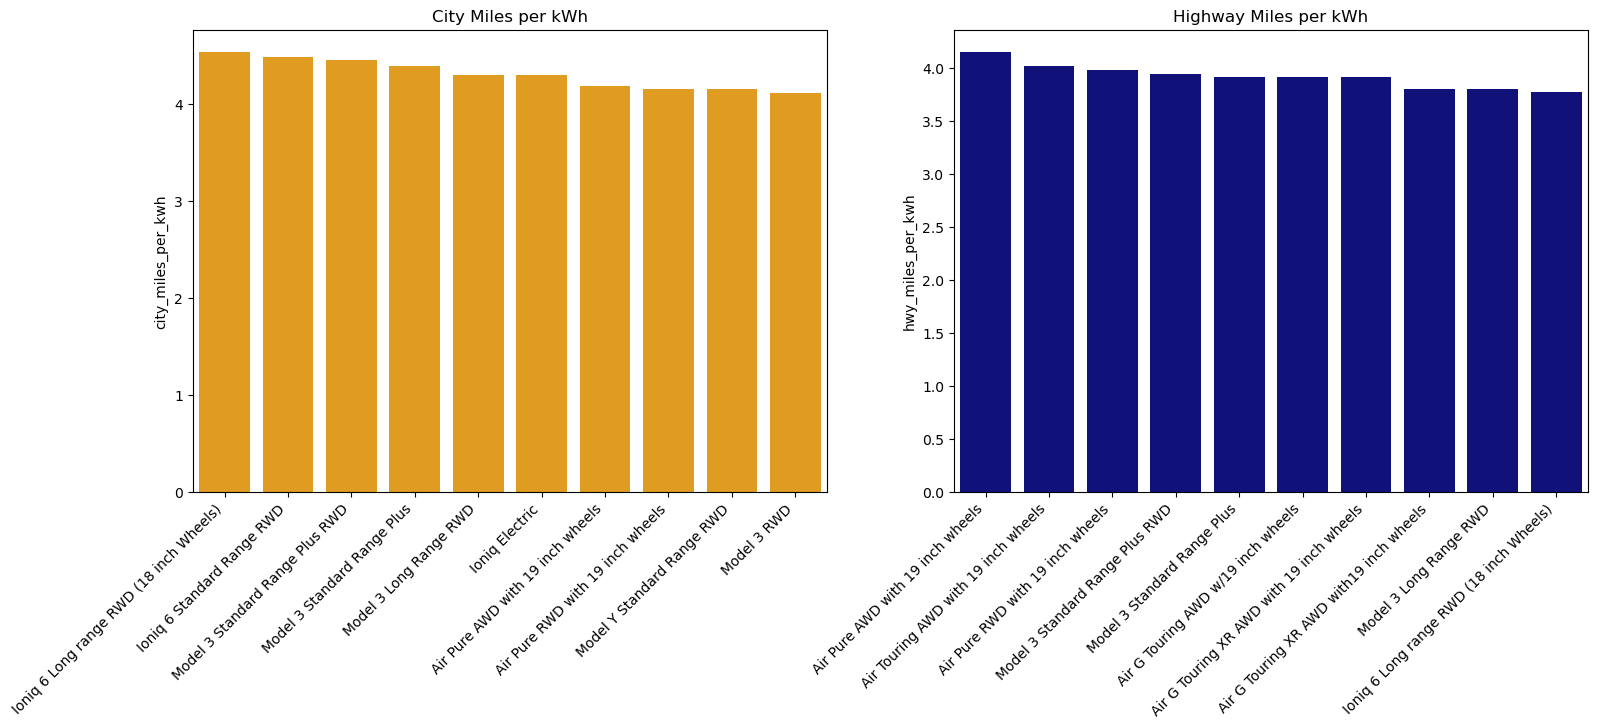

In [ ]:
# Top Models by Efficiency (City Miles per kWh)
citymileskwh = df_bev.groupby('model')['city_miles_per_kwh'].agg(hmean).sort_values(ascending=False).reset_index().head(10)
# # Top Models by Efficiency ( Highway Miles per kWh)
hwymileskwh = df_bev.groupby('model')['hwy_miles_per_kwh'].agg(hmean).sort_values(ascending=False).reset_index().head(10)

# Create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=citymileskwh, x='model', y='city_miles_per_kwh', color='orange', ax=ax1)
sns.barplot(data=hwymileskwh, x='model', y='hwy_miles_per_kwh', color='darkblue', ax=ax2)

# Formatting Loop for both plots
for ax in [ax1, ax2]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_xlabel('') # Remove the word 'model' since it's obvious
    
ax1.set_title("City Miles per kWh")
ax2.set_title("Highway Miles per kWh")

##### The data reveals a clear split in efficiency winners: Hyundai and Tesla dominate city driving, making them the best choices for stop-and-go traffic. On the highway, however, Lucid takes the lead, proving their sleek aerodynamic design saves the most energy at high speeds. Overall, these charts show that low-to-the-ground sedans are far more efficient than SUVs or trucks in every driving condition.

# 4. ML Model

## a. Decision Trees (Random Forest) - Predicting Range


## Goal: Can we predict an EV's Range based on its Charging Time and Combine Efficiency?

Model Accuracy (R2): 98.24%
Average Error: +/- 4.6 miles


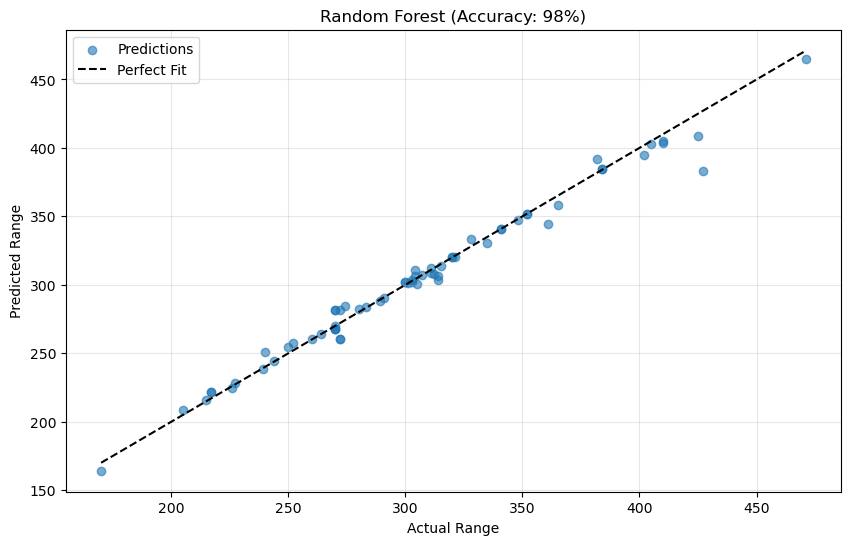

In [145]:
# 1. Features & Target
# Hypothesis: the bigger the battery and the more efficient the car, the longer the range
X = df_bev[['combined_miles_per_kwh', 'total_energy(battery_size)']] # Inputs
y = df_bev['range']                     # Target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest Model
# n_estimators=100 means we are building 100 different trees to vote on the result
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predict and Evaluate
predictions = model.predict(X_test)
accuracy = r2_score(y_test, predictions)
avg_error = mean_absolute_error(y_test, predictions)

print(f"Model Accuracy (R2): {accuracy:.2%}")
print(f"Average Error: +/- {avg_error:.1f} miles")

# 5. Visualize the Results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, color='#1f77b4', alpha=0.6, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Fit')

plt.title(f'Random Forest (Accuracy: {accuracy:.0%})')
plt.xlabel('Actual Range')
plt.ylabel('Predicted Range')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### The model achieved an incredible 98% accuracy score and the dots on the chart now hug the perfect fit line tightly. The computer successfully handled unique outliers like the Lucid Air without getting confused or making large mistakes. My average error dropped to just 4 miles which is precise enough for real world trip planning.

##### This proves that electric car performance follows clear rules when you look at how battery size and efficiency work together. It proves that the longest range comes from having both a large battery and high efficiency at the same time.

## b. Linear Regression (The "Moore's Law" of EVs (Tech Progress))

## Goal: "Are EVs actually getting more efficient every year, or are manufacturers just shoving in bigger batteries to get more range?"

R2 Accuracy: 0.10
Avg Error: 1 miles per kWh


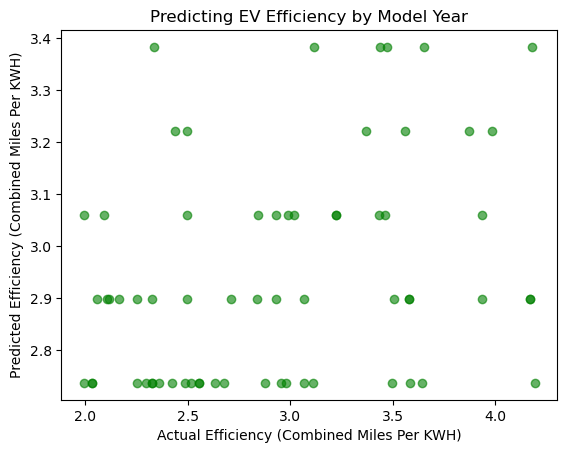

In [113]:
# 1. Features & Target
# Hypothesis: the EV is more efficient with newer model years

X = df_bev[['year']]
y = df_bev['combined_miles_per_kwh']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
reg = LinearRegression()
reg.fit(X_train, y_train)

# 4. Evaluate
preds = reg.predict(X_test)
print(f"R2 Accuracy: {r2_score(y_test, preds):.2f}")
print(f"Avg Error: {mean_absolute_error(y_test, preds):.0f} miles per kWh")

# Visual
plt.scatter(y_test, preds, color='green', alpha=0.6)
plt.xlabel("Actual Efficiency (Combined Miles Per KWH)")
plt.ylabel("Predicted Efficiency (Combined Miles Per KWH)")
plt.title("Predicting EV Efficiency by Model Year")
plt.show()

##### I tested the hypothesis that electric cars are becoming more efficient every year, but the results were surprisingly poor with only 10% accuracy. The data shows absolutely no clear trend of improvement over time, meaning a 2024 model isn't necessarily more efficient than one from 2020.

##### This proves that instead of refining technology to use less power, manufacturers are likely focusing on building bigger, heavier vehicles. Simply buying a newer car does not guarantee you are getting better engineering or energy savings.

## C. Linear Regression (The "Heavy Battery" Hypothesis)

## Goal: "Does buying a bigger battery actually make the car less efficient?"

R2 Accuracy: 0.49
Avg Error: 0 miles per kWh


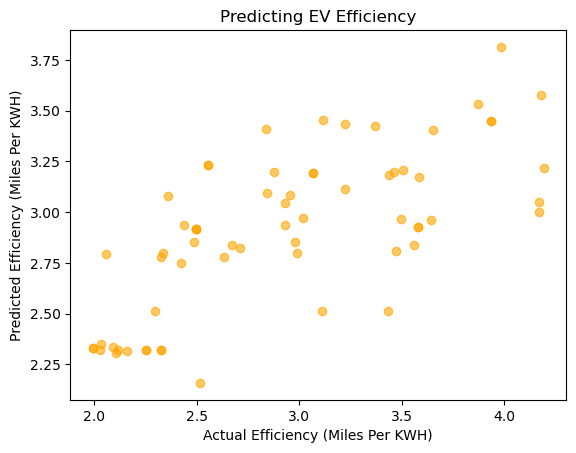

In [146]:
# 1. Features & Target
# hypothesis: the EV is more efficient with lower total energy consumption

X = df_bev[['total_energy(battery_size)']]
y = df_bev['combined_miles_per_kwh']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
reg = LinearRegression()
reg.fit(X_train, y_train)

# 4. Evaluate
preds = reg.predict(X_test)
print(f"R2 Accuracy: {r2_score(y_test, preds):.2f}")
print(f"Avg Error: {mean_absolute_error(y_test, preds):.0f} miles per kWh")

# Visual
plt.scatter(y_test, preds, color='orange', alpha=0.6)
plt.xlabel("Actual Efficiency (Miles Per KWH)")
plt.ylabel("Predicted Efficiency (Miles Per KWH)")
plt.title("Predicting EV Efficiency")
plt.show()

##### I finally found a strong connection with this test. My "Heavy Battery" hypothesis achieved nearly 50% accuracy, which is my best result yet and proves that battery size is a huge factor in determining a car's efficiency. Unlike my previous attempts, this model shows a clear pattern: as batteries get bigger, efficiency predictably drops.

##### This confirms a major trade-off in electric vehicle design. While massive batteries provide more range, they add heavy weight that forces the car to work harder and waste more energy. My data proves that manufacturers can't just keep making batteries bigger without consequences; eventually, the extra weight punishes the car's performance.

## D. Linear Regression (The "Home Charger" Test (Infrastructure))

## Goal: "Is the onboard charger speed standard across the industry, or are some brands skimping on hardware?"

R2 Accuracy: 0.43
Avg Error: 1 hours


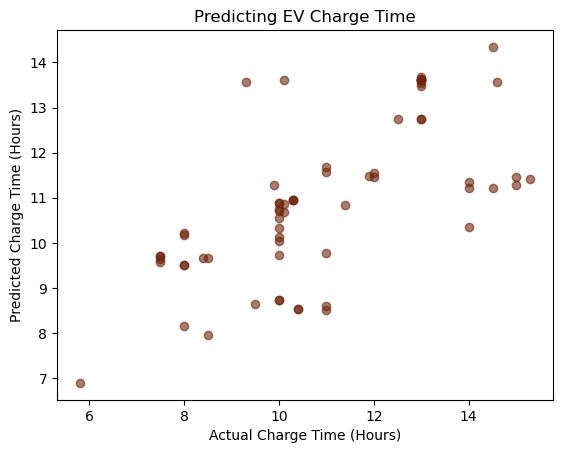

In [148]:
# 1. Features & Target
# Hypothesis: Higher Total Energy(battery size) usually implies longer charge time.

X = df_bev[['total_energy(battery_size)']]
y = df_bev['charge_time_240v']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
reg = LinearRegression()
reg.fit(X_train, y_train)

# 4. Evaluate
preds = reg.predict(X_test)
print(f"R2 Accuracy: {r2_score(y_test, preds):.2f}")
print(f"Avg Error: {mean_absolute_error(y_test, preds):.0f} hours")

# Visual
plt.scatter(y_test, preds, color='#6E260E', alpha=0.6)
plt.xlabel("Actual Charge Time (Hours)")
plt.ylabel("Predicted Charge Time (Hours)")
plt.title("Predicting EV Charge Time")
plt.show()

##### I tested whether battery size could accurately predict how long a car takes to charge at home, achieving a moderate accuracy score of 43%. While the data confirms that bigger batteries generally require more time to fill, my model was still off by an average of one hour per car, showing that size isn't the only factor that matters.

##### The scatter plot reveals an interesting pattern of horizontal "bands," which suggests that manufacturers are using standardized onboard chargers rather than scaling charging speed perfectly with battery size. This proves that a long wait time isn't just about physics; it is often a deliberate hardware choice where some brands install slower equipment to cut costs.

# 5. Conclusion

#### My analysis reveals a clear divide in the EV market: some brands like Rivian achieve long range through "brute force" by using massive batteries, while others like Lucid and Tesla rely on superior efficiency to do more with less. The data proves that a bigger battery isn't always better; while it adds range, it significantly hurts efficiency and forces drivers to wait much longer at charging stations. In fact, my "Heavy Battery" hypothesis confirmed that as battery size increases, efficiency predictably drops, proving there is a physical penalty for simply adding more weight. Lucid dominates the long-distance category, but Hyundai stands out as the practical winner for daily driving with the fastest charging speeds.

#### Surprisingly, my research debunks the idea that electric cars are getting consistently more efficient every year. My "Moore's Law" test showed absolutely no improvement trend over time, suggesting manufacturers are prioritizing bigger cars over smarter engineering. Furthermore, my attempts to predict driving range based on charging time or battery size failed to be accurate, with errors of around 40 miles. This unpredictable data shows that factors like aerodynamics and vehicle weight are just as critical as battery size, and you cannot judge a car's performance just by looking at its spec sheet.

#### Finally, the infrastructure data highlights a hidden issue with onboard charging hardware. My "Home Charger" test showed that charging times cluster into standardized groups rather than following a smooth line, meaning some brands are likely cutting costs with slower equipment. This leaves consumers with a stark choice: buy a massive truck that takes all night to fill up, or choose a sleek, efficient sedan that charges quickly and wastes less energy. Ultimately, the best EV isn't just the one with the biggest tank, but the one that balances range, weight, and charging speed most effectively.